## **Linear Regression: Implementation with NumPy**

First, we implement a class called Linear RegressionManual which contains the following methods:

**fit** method for training

**predict** method for predicting

**score** method for evaluating

**plot_cost_history** for visualizing the training

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


class LinearRegressionManual:
    def __init__(self, learning_rate=0.01, n_iterations=1000, method="gradient_descent"):
        """
               Initialize the Linear Regression model.

               Parameters:
               -----------
               learning_rate : float
                   Step size for gradient descent (default: 0.01)
               n_iterations : int
                   Number of iterations for gradient descent (default: 1000)
               method : str
                   'gradient_descent' or 'normal_equation' (default: 'gradient_descent')
               """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.method = method
        self.theta = None
        self.cost_history = []

    def _add_intercept(self, X):
        """Add intercept term (column of ones) to feature matrix."""
        ones_column = np.ones((X.shape[0], 1))
        x_with_intercept = np.concatenate((ones_column, X), axis=1)
        return x_with_intercept

    def _compute_cost(self, X, y, theta):
        """
    Compute the Mean Squared Error cost function.
    J(θ) = (1/2m) * Σ(h(x) - y)²
            """
        m = len(y)
        predictions = X @ theta
        cost = np.sum((predictions - y) ** 2) * (1 / (2 * m))
        return cost

    def _gradient_descent(self, X, y):
        """
                Perform gradient descent to learn theta parameters.

                Update rule: θⱼ := θⱼ - α * (1/m) * Σ(h(x) - y) * xⱼ
                """
        m = len(y)
        self.theta = np.zeros((X.shape[1], 1))

        for i in range(self.n_iterations):
            predictions = X @ self.theta
            errors = predictions - y
            gradient = (1/m) * (X.T @ errors)
            self.theta -= self.learning_rate * gradient

            cost = self._compute_cost(X, y, self.theta)
            self.cost_history.append(cost)

            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")

    def _normal_equation(self, X, y):
        """
               Compute theta using the normal equation (closed-form solution).

               θ = (XᵀX)⁻¹Xᵀy
               """
        self.theta = np.linalg.inv(X.T @ X) @ X.T @ y
        cost = self._compute_cost(X, y, self.theta)
        print(f"Normal equation - Final Cost: {cost:.4f}")

    def fit(self, X, y):
        """
              Train the linear regression model.

              Parameters:
              -----------
              X : numpy array of shape (m, n)
                  Training features
              y : numpy array of shape (m, 1) or (m,)
                  Training labels
              """
        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        x_with_intercept = self._add_intercept(X)

        if self.method == "gradient_descent":
            print("Training with gradient descent...")
            self._gradient_descent(x_with_intercept, y)
        elif self.method == "normal_equation":
            print("Training with normal equation...")
            self._normal_equation(x_with_intercept, y)
        else:
            raise ValueError("Method name wrong!")

        print(f"Training complete! Final theta: {self.theta.ravel()}")

    def predict(self, X):
        """
               Make predictions using the learned parameters.

               Parameters:
               -----------
               X : numpy array of shape (m, n)
                   Features to predict

               Returns:
               --------
               predictions : numpy array of shape (m, 1)
                   Predicted values
               """
        x_with_intercept = self._add_intercept(X)
        return x_with_intercept @ self.theta

    def score(self, X, y):
        """
R² measures how well your regression model explains the variance in the data —
in other words, how good your predictions are compared to just predicting the mean of the target.
                Calculate R² score (coefficient of determination).

                R² = 1 - (SS_res / SS_tot)
                """
        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        predictions = self.predict(X)
        ss_res = np.sum((y - predictions) ** 2)
        ss_tot = np.sum((y-np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        return r2



SIMPLE LINEAR REGRESSION WITH A SINGLE FEATURE
Training with gradient descent...
Iteration 0: Cost = 47.5229
Iteration 100: Cost = 4.5019
Iteration 200: Cost = 4.1301
Iteration 300: Cost = 3.9168
Iteration 400: Cost = 3.7944
Iteration 500: Cost = 3.7242
Iteration 600: Cost = 3.6839
Iteration 700: Cost = 3.6608
Iteration 800: Cost = 3.6475
Iteration 900: Cost = 3.6399
Training complete! Final theta: [3.4411451  1.89344452]
Training with normal equation...
Normal equation - Final Cost: 3.6296
Training complete! Final theta: [3.64528847 1.86206803]

Gradient Descent - R² Train: 0.8068, Test: 0.7864
Normal Equation - R² Train: 0.8071, Test: 0.7829


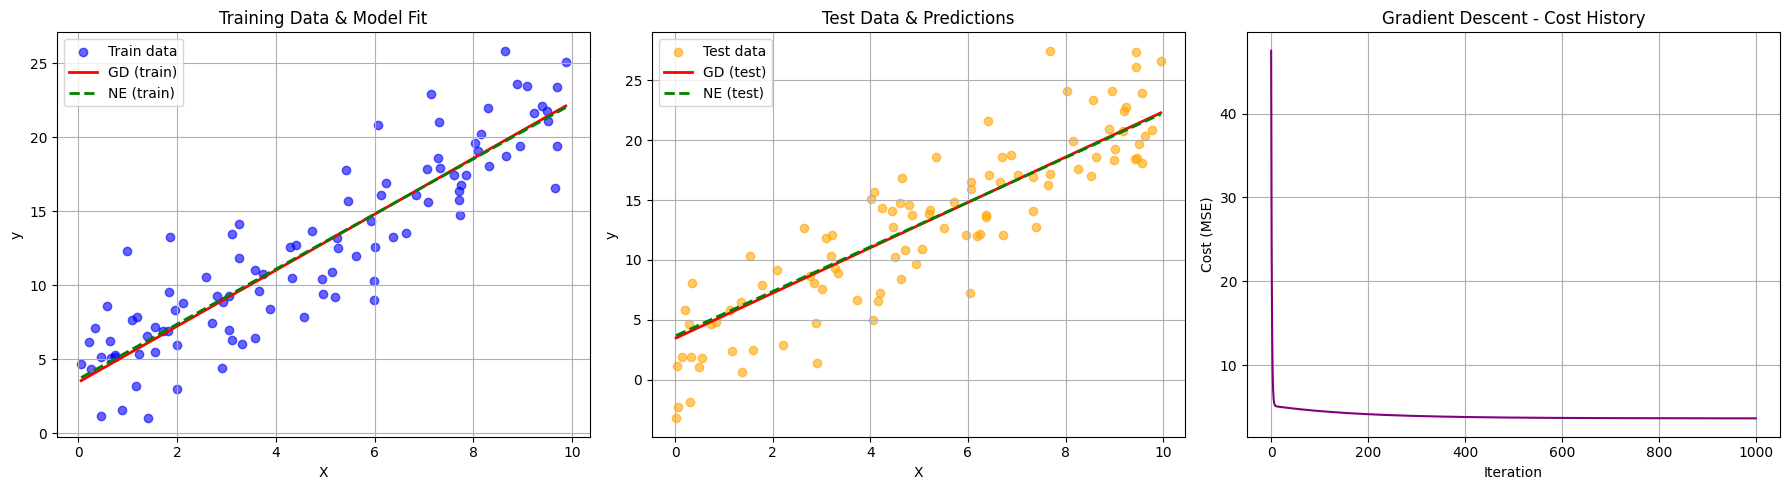

MULTIPLE LINEAR REGRESSION WITH THREE FEATURES
Training with gradient descent...
Iteration 0: Cost = 54.5732
Iteration 100: Cost = 2.5968
Iteration 200: Cost = 2.4599
Iteration 300: Cost = 2.3479
Iteration 400: Cost = 2.2561
Iteration 500: Cost = 2.1809
Iteration 600: Cost = 2.1194
Iteration 700: Cost = 2.0689
Iteration 800: Cost = 2.0276
Iteration 900: Cost = 1.9938
Training complete! Final theta: [ 2.89232563  3.15437817  1.55059896 -1.77948042]
Training with normal equation...
Normal equation - Final Cost: 1.8408
Training complete! Final theta: [ 4.47002911  3.05560082  1.46844756 -1.88591885]

Gradient Descent - R² Train: 0.9724, Test: 0.9691
Normal Equation - R² Train: 0.9741, Test: 0.9736


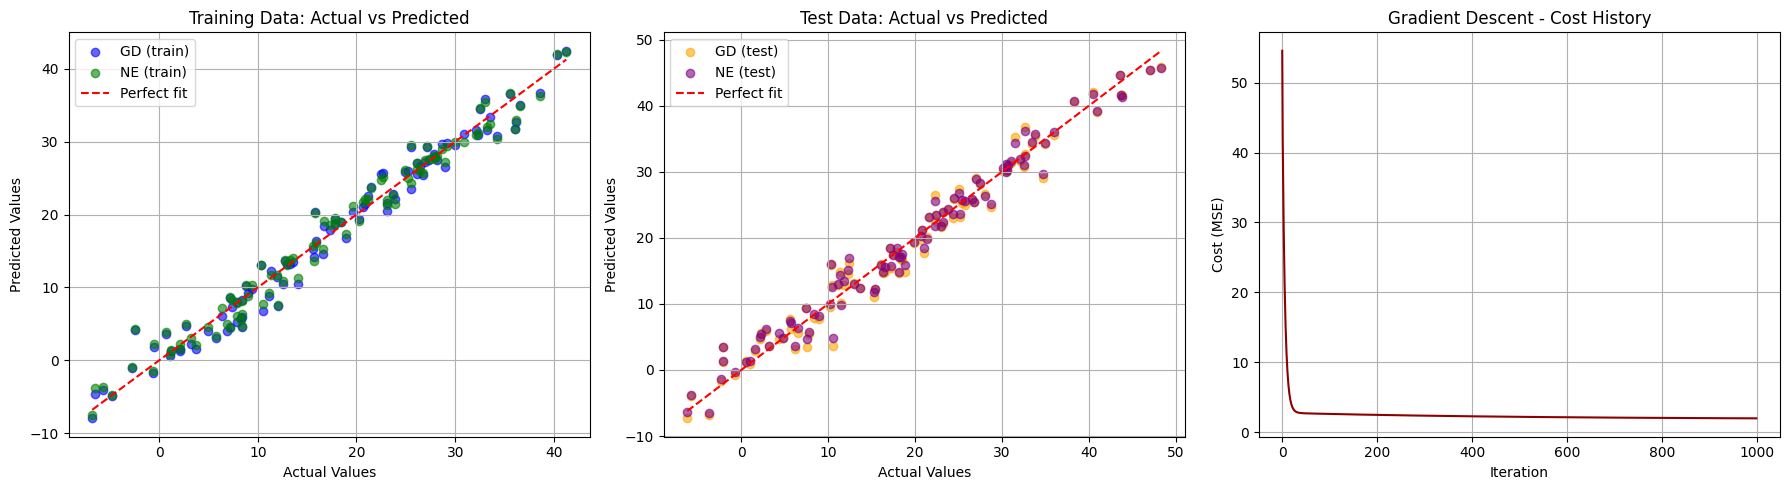

In [ ]:
#from LinearRegressionManual import LinearRegressionManual
#import numpy as np
#import matplotlib.pyplot as plt


def main():
    example_simple_regression()
    example_multiple_regression()


def example_simple_regression():
    print("SIMPLE LINEAR REGRESSION WITH A SINGLE FEATURE")

    # --- Data generation ---
    # Generate synthetic data: y = 3 + 2*x + noise
    np.random.seed(42)
    X_train = np.random.rand(100, 1) * 10
    y_train = 3 + 2 * X_train + np.random.randn(100, 1) * 3

    np.random.seed(12)
    X_test = np.random.rand(100, 1) * 10
    y_test = 3 + 2 * X_test + np.random.randn(100, 1) * 3

    # --- Model training ---
    model_gd = LinearRegressionManual(learning_rate=0.01, n_iterations=1000,
                                      method="gradient_descent")
    model_gd.fit(X_train, y_train)

    model_ne = LinearRegressionManual(method="normal_equation")
    model_ne.fit(X_train, y_train)

    # --- Predictions ---
    y_pred_train_gd = model_gd.predict(X_train)
    y_pred_test_gd = model_gd.predict(X_test)
    y_pred_train_ne = model_ne.predict(X_train)
    y_pred_test_ne = model_ne.predict(X_test)

    # --- Evaluation ---
    r2_gd_train = model_gd.score(X_train, y_train)
    r2_gd_test = model_gd.score(X_test, y_test)
    r2_ne_train = model_ne.score(X_train, y_train)
    r2_ne_test = model_ne.score(X_test, y_test)

    print(f"\nGradient Descent - R² Train: {r2_gd_train:.4f}, Test: {r2_gd_test:.4f}")
    print(f"Normal Equation - R² Train: {r2_ne_train:.4f}, Test: {r2_ne_test:.4f}")

    # --- Plot results ---
    plt.figure(figsize=(18, 5))

    # 1️⃣ Training Data Plot
    plt.subplot(1, 3, 1)
    plt.scatter(X_train, y_train, alpha=0.6, label='Train data', color='blue')

    sorted_train_idx = np.argsort(X_train[:, 0])
    plt.plot(X_train[sorted_train_idx], y_pred_train_gd[sorted_train_idx],
             'r-', label='GD (train)', linewidth=2)
    plt.plot(X_train[sorted_train_idx], y_pred_train_ne[sorted_train_idx],
             'g--', label='NE (train)', linewidth=2)

    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Training Data & Model Fit')
    plt.legend()
    plt.grid(True)

    # 2️⃣ Test Data Plot
    plt.subplot(1, 3, 2)
    plt.scatter(X_test, y_test, alpha=0.6, label='Test data', color='orange')

    sorted_test_idx = np.argsort(X_test[:, 0])
    plt.plot(X_test[sorted_test_idx], y_pred_test_gd[sorted_test_idx],
             'r-', label='GD (test)', linewidth=2)
    plt.plot(X_test[sorted_test_idx], y_pred_test_ne[sorted_test_idx],
             'g--', label='NE (test)', linewidth=2)

    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Test Data & Predictions')
    plt.legend()
    plt.grid(True)

    # 3️⃣ Cost History (for Gradient Descent)
    plt.subplot(1, 3, 3)
    plt.plot(model_gd.cost_history, color='purple')
    plt.xlabel('Iteration')
    plt.ylabel('Cost (MSE)')
    plt.title('Gradient Descent - Cost History')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def example_multiple_regression():
    print("MULTIPLE LINEAR REGRESSION WITH THREE FEATURES")

    # --- Data generation ---
    np.random.seed(42)
    X_train = np.random.rand(100, 3) * 10
    true_weights = np.array([[3], [1.5], [-2]])
    y_train = 5 + X_train @ true_weights + np.random.randn(100, 1) * 2

    np.random.seed(12)
    X_test = np.random.rand(100, 3) * 10
    y_test = 5 + X_test @ true_weights + np.random.randn(100, 1) * 2

    # --- Model training ---
    model_gd = LinearRegressionManual(learning_rate=0.01, n_iterations=1000, method="gradient_descent")
    model_gd.fit(X_train, y_train)

    model_ne = LinearRegressionManual(method="normal_equation")
    model_ne.fit(X_train, y_train)

    # --- Predictions ---
    y_pred_train_gd = model_gd.predict(X_train)
    y_pred_test_gd = model_gd.predict(X_test)
    y_pred_train_ne = model_ne.predict(X_train)
    y_pred_test_ne = model_ne.predict(X_test)

    # --- Evaluation ---
    r2_gd_train = model_gd.score(X_train, y_train)
    r2_gd_test = model_gd.score(X_test, y_test)
    r2_ne_train = model_ne.score(X_train, y_train)
    r2_ne_test = model_ne.score(X_test, y_test)

    print(f"\nGradient Descent - R² Train: {r2_gd_train:.4f}, Test: {r2_gd_test:.4f}")
    print(f"Normal Equation - R² Train: {r2_ne_train:.4f}, Test: {r2_ne_test:.4f}")

    # --- Plot results ---
    plt.figure(figsize=(18, 5))

    # 1️⃣ Training Data Plot
    plt.subplot(1, 3, 1)
    plt.scatter(y_train, y_pred_train_gd, alpha=0.6, color='blue', label='GD (train)')
    plt.scatter(y_train, y_pred_train_ne, alpha=0.6, color='green', label='NE (train)')
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', label='Perfect fit')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Training Data: Actual vs Predicted')
    plt.legend()
    plt.grid(True)

    # 2️⃣ Test Predictions vs Actual
    plt.subplot(1, 3, 2)
    plt.scatter(y_test, y_pred_test_gd, alpha=0.6, color='orange', label='GD (test)')
    plt.scatter(y_test, y_pred_test_ne, alpha=0.6, color='purple', label='NE (test)')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect fit')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Test Data: Actual vs Predicted')
    plt.legend()
    plt.grid(True)

    # 3️⃣ Cost History (only GD)
    plt.subplot(1, 3, 3)
    plt.plot(model_gd.cost_history, color='darkred')
    plt.xlabel('Iteration')
    plt.ylabel('Cost (MSE)')
    plt.title('Gradient Descent - Cost History')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
